In [ ]:
#Nguyễn Anh Vũ

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
#  Khai báo các tham số
DATASET_PATH = "/content/drive/MyDrive/datadoan/plant-health"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
#  ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2
)
#  Train generator
train_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)
#  Validation generator
val_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 566 images belonging to 2 classes.
Found 141 images belonging to 2 classes.


In [ ]:
#  MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


In [ ]:

# Train model
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

train_time = time.time() - start_time
print(f"Thời gian huấn luyện: {train_time:.2f} giây")

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.5047 - loss: 0.7935 - val_accuracy: 0.5461 - val_loss: 0.6916 - learning_rate: 1.0000e-04
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6883 - loss: 0.5908 - val_accuracy: 0.4255 - val_loss: 0.7678 - learning_rate: 1.0000e-04
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7831 - loss: 0.4795 - val_accuracy: 0.4539 - val_loss: 0.8085 - learning_rate: 1.0000e-04
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.7918 - loss: 0.4345 - val_accuracy: 0.4894 - val_loss: 0.7925 - learning_rate: 1.0000e-04
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7863 - loss: 0.4408 - val_accuracy: 0.4752 - val_loss: 0.8141 - learning_rate: 3.0000e-05
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8360 - loss: 0.4103 - val_accuracy: 0.4610 - val_loss: 0.8395 - learning_rate: 3.0000e-05
Thời gian huấn luyện: 290.84 giây


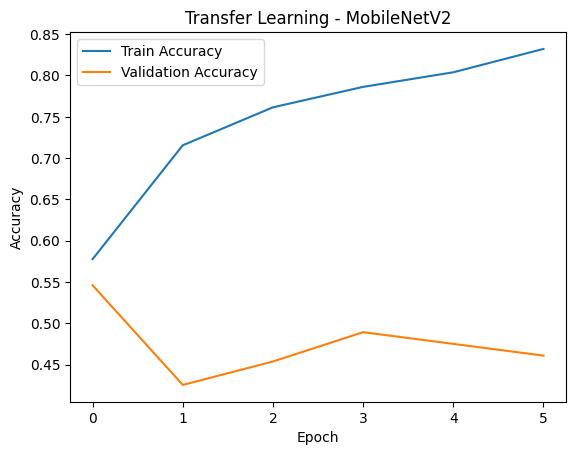

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning - MobileNetV2")
plt.legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Accuracy trên tập validation: 0.5035

Classification Report:
              precision    recall  f1-score   support

     healthy       0.48      0.75      0.58        65
   unhealthy       0.58      0.29      0.39        76

    accuracy                           0.50       141
   macro avg       0.53      0.52      0.48       141
weighted avg       0.53      0.50      0.48       141



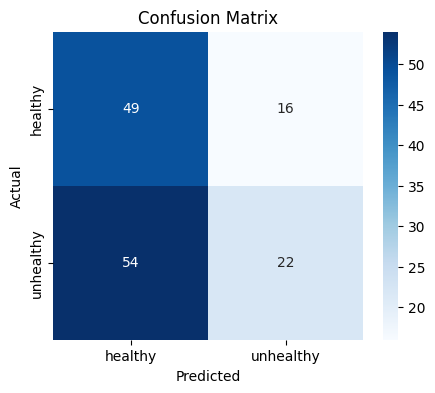

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy nhãn thật
y_true = val_generator.classes

# Dự đoán
y_pred_prob = model.predict(val_generator)           # ra xác suất
y_pred = (y_pred_prob > 0.5).astype(int).ravel()    # chuyển sang nhãn 0 hoặc 1

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy trên tập validation: {acc:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

# Confusion Matrix trực quan
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

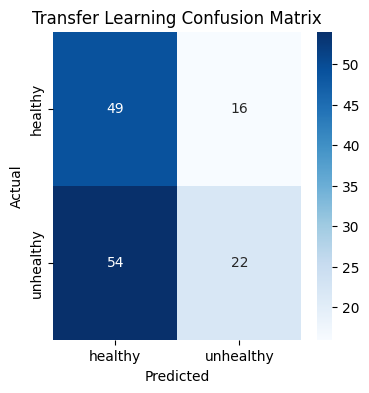

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")
plt.show()


In [ ]:
print(f"Thời gian huấn luyện: {train_time:.2f} giây")


Thời gian huấn luyện: 955.32 giây
